# 07 — Topic Modeling
### IndicNews AI — Hindi News Analysis, Retrieval & Recommendation System

Trains both LDA and NMF  and
compares them on real topic-word coherence 

In [2]:
import sys
sys.path.append("..")

import time
import numpy as np
import pandas as pd
import joblib
import scipy.sparse as sp
import matplotlib.pyplot as plt

from data_utils import load_dataset
from preprocessing import preprocess_pipeline
from feature_engineering import build_count_vectorizer, build_combined_token_field
from topic_modeling import (
    build_lda_model, build_nmf_model, get_top_words_per_topic,
    get_dominant_topic, topic_category_crosstab,
)


import matplotlib.font_manager as fm


plt.rcParams["font.family"] = ["Nirmala UI", "DejaVu Sans"]

pd.set_option("display.max_colwidth", 80)
N_TOPICS = 7  

In [3]:
df = load_dataset(verbose=False)
uniq = df.drop_duplicates(subset=["Headline", "Content"]).reset_index(drop=True)
clean_df = preprocess_pipeline(uniq, columns=["Headline", "Content"])
combined_tokens = build_combined_token_field(clean_df)
print(clean_df.shape)

(34826, 11)


## 1. Train LDA (on raw word counts)

Fresh unigram-only `CountVectorizer` — LDA is a generative model over
raw counts, and unigrams keep the resulting topic-word lists
interpretable (n-grams tend to fragment topics into phrase-soup).

In [4]:
count_vec = build_count_vectorizer(ngram_range=(1, 1))
X_counts = count_vec.fit_transform(combined_tokens)
print("Count matrix shape:", X_counts.shape)

t0 = time.time()
lda_model = build_lda_model(X_counts, n_topics=N_TOPICS)
print(f"LDA trained in {time.time() - t0:.1f}s")

Count matrix shape: (34826, 12593)
LDA trained in 214.6s


In [5]:
lda_topics = get_top_words_per_topic(lda_model, count_vec.get_feature_names_out(), n_words=10)
for topic_idx, words in lda_topics.items():
    print(f"Topic {topic_idx}: {', '.join(words)}")

Topic 0: टीम, मैच, भारत, भारतीय, कप, विश्व, खेल, जीत, खिलाफ, रन
Topic 1: चुनाव, भारत, लोकसभ, बीजेप, मोद, प्रधानमंत्र, सीट, मंत्र, पूर्व, 2024
Topic 2: वीडिय, मैं, तस्वीर, फिल्म, शेयर, मेर, हूं, दिख, वायरल, मुझ
Topic 3: पुलिस, लोग, महिल, आरोप, प्रदेश, मौत, शख्स, बिहार, यूप, वर्षीय
Topic 4: कांग्रेस, अमेरिक, राहुल, गांध, क्य, खा, चाह, लोग, महिल, बयान
Topic 5: करोड़, 1, कम, साल, लाख, 2, अधिक, 5, शेयर, 000
Topic 6: शाद, इज़रायल, कोर्ट, मामल, जेल, हमल, अंबा, हमास, हाईकोर्ट, खिलाफ


## 2. Train NMF (on TF-IDF)



In [6]:
tfidf_vectorizer = joblib.load("../../models/saved_models/tfidf_vectorizer.joblib")
X_tfidf = sp.load_npz("../../models/saved_models/tfidf_matrix.npz")
print("TF-IDF matrix shape:", X_tfidf.shape)

t0 = time.time()
nmf_model = build_nmf_model(X_tfidf, n_topics=N_TOPICS)
print(f"NMF trained in {time.time() - t0:.1f}s")

TF-IDF matrix shape: (34826, 60359)
NMF trained in 3.2s


In [7]:
nmf_topics = get_top_words_per_topic(nmf_model, tfidf_vectorizer.get_feature_names_out(), n_words=10)
for topic_idx, words in nmf_topics.items():
    print(f"Topic {topic_idx}: {', '.join(words)}")

Topic 0: पुलिस, आरोप, महिल, वर्षीय, शख्स, हत्य, मौत, मामल, लोग, गिरफ्तार
Topic 1: कप, विश्व कप, विश्व, टी20, मैच, टी20 विश्व, टी20 विश्व कप, टीम, भारतीय, रन
Topic 2: चुनाव, लोकसभ, बीजेप, सीट, लोकसभ चुनाव, कांग्रेस, उम्मीदवार, पार्ट, ने, लोकसभ सीट
Topic 3: वीडिय, तस्वीर, फिल्म, शेयर, वायरल, मैं, दिख, मीडिय, सोशल, सोशल मीडिय
Topic 4: करोड़, 1, भारत, साल, लाख, कंप, कम, अधिक, 5, 2
Topic 5: मोद, प्रधानमंत्र, पीएम, नरेंद्र मोद, नरेंद्र, प्रधानमंत्र नरेंद्र, प्रधानमंत्र नरेंद्र मोद, पीएम मोद, भारत, देश
Topic 6: केजरीवाल, दिल्ल, अरविंद, अरविंद केजरीवाल, मुख्यमंत्र, कोर्ट, मुख्यमंत्र अरविंद, मुख्यमंत्र अरविंद केजरीवाल, दिल्ल मुख्यमंत्र, दिल्ल मुख्यमंत्र अरविंद


## 3. Topic visualization — top words per topic, side by side

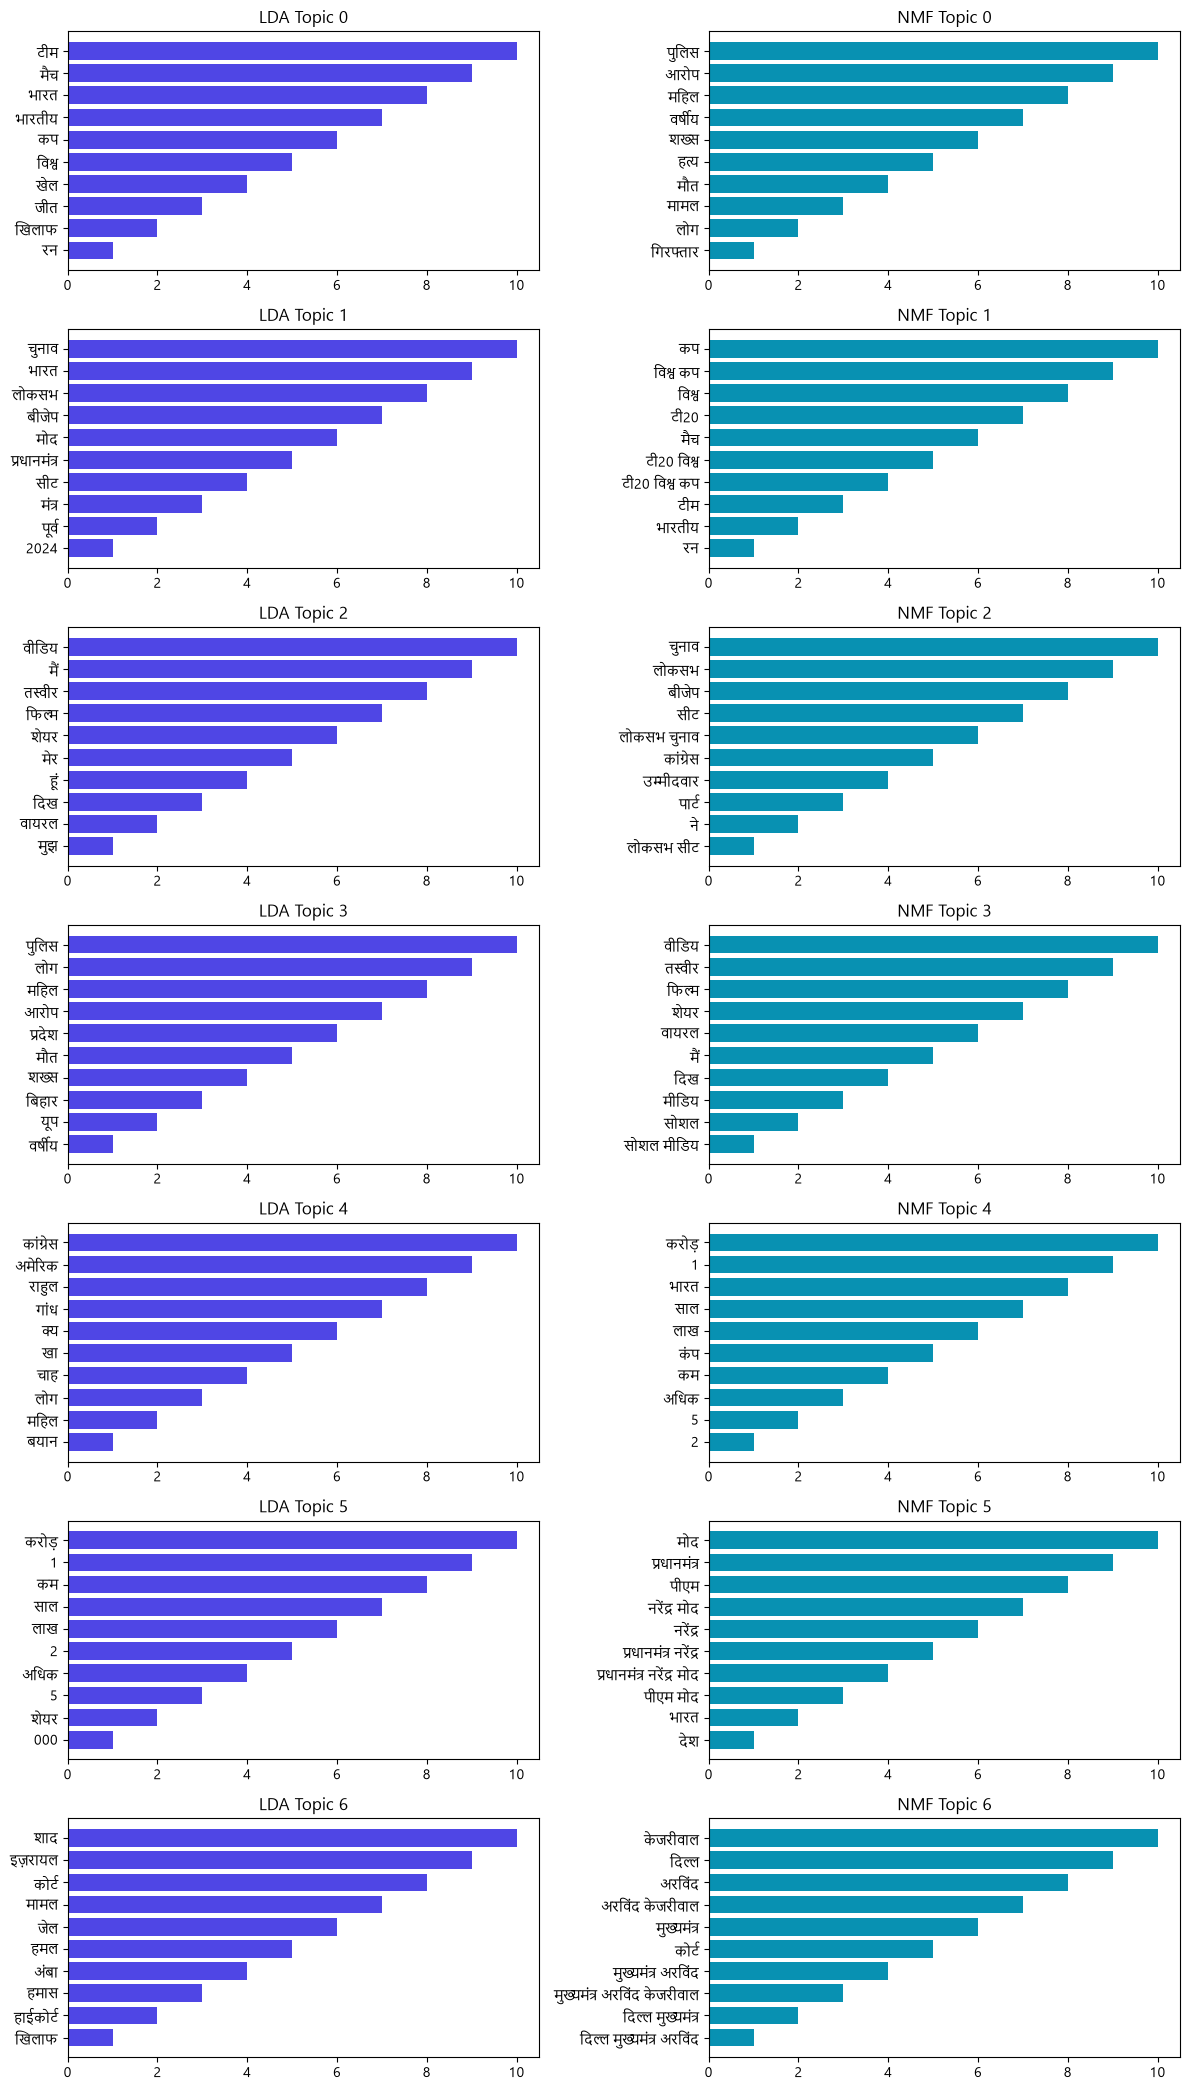

In [8]:
fig, axes = plt.subplots(N_TOPICS, 2, figsize=(12, 3 * N_TOPICS))
for topic_idx in range(N_TOPICS):
    for col, (topics, label) in enumerate([(lda_topics, "LDA"), (nmf_topics, "NMF")]):
        ax = axes[topic_idx, col]
        words = topics[topic_idx][::-1]
        ax.barh(words, range(1, len(words) + 1), color="#4f46e5" if col == 0 else "#0891b2")
        ax.set_title(f"{label} Topic {topic_idx}")
plt.tight_layout()
plt.show()

## 4. Dominant topic per document, cross-checked against known categories

Not a formal evaluation (topic modeling is unsupervised, no alignment
guarantee) — just a readable sanity check on whether discovered topics
correspond to something coherent.

In [9]:
lda_dominant = get_dominant_topic(lda_model, X_counts)
nmf_dominant = get_dominant_topic(nmf_model, X_tfidf)

lda_crosstab = topic_category_crosstab(lda_dominant, clean_df["core_categories"], N_TOPICS)
nmf_crosstab = topic_category_crosstab(nmf_dominant, clean_df["core_categories"], N_TOPICS)

print("LDA topic -> category breakdown:")
for t, counts in lda_crosstab.items():
    print(f"  Topic {t}: {counts}")

print()
print("NMF topic -> category breakdown:")
for t, counts in nmf_crosstab.items():
    print(f"  Topic {t}: {counts}")

LDA topic -> category breakdown:
  Topic 0: {'national': 70, 'politics': 12, 'sports': 4365, 'other': 36, 'entertainment': 10, 'business': 7, 'technology': 4}
  Topic 1: {'politics': 2092, 'national': 1316, 'business': 97, 'sports': 183, 'technology': 103, 'entertainment': 55, 'other': 729}
  Topic 2: {'national': 429, 'politics': 415, 'entertainment': 3881, 'sports': 706, 'business': 216, 'technology': 157, 'other': 618}
  Topic 3: {'national': 5429, 'politics': 1415, 'entertainment': 313, 'business': 53, 'sports': 92, 'technology': 9, 'other': 953}
  Topic 4: {'national': 415, 'politics': 483, 'business': 48, 'sports': 32, 'technology': 144, 'entertainment': 108, 'other': 433}
  Topic 5: {'business': 2763, 'national': 1846, 'politics': 324, 'sports': 138, 'technology': 701, 'entertainment': 176, 'other': 1184}
  Topic 6: {'national': 642, 'business': 365, 'politics': 299, 'sports': 25, 'technology': 170, 'entertainment': 183, 'other': 582}

NMF topic -> category breakdown:
  Topic 0:

## 5. Save the chosen model

Run after deciding LDA vs NMF from §1-4 above.

In [10]:
# Adjust which one to keep based on which produced more coherent topics:
joblib.dump(nmf_model, "../../models/saved_models/topic_model_nmf.joblib")
joblib.dump(lda_model, "../../models/saved_models/topic_model_lda.joblib")
joblib.dump(count_vec, "../../models/saved_models/count_vectorizer.joblib")
print("Saved both models (decide which is primary in the summary below).")

Saved both models (decide which is primary in the summary below).
